# <font color=red> Melanoma Detection (TO BE DONE IN GOOGLE COLAB)
##### https://colab.research.google.com/drive/1z3zytZ2Dqcva-Mz9C3qY_1GRTjfqTOBb

## <font color=green>Bookmarks to Notebook Sections
 - [Importing all the important libraries](#import_libraries)
 - [Data Preparation](#data_preparation)
 - - [Train Data Set Creation](#train_data)
 - - [Validation Data Set Creation](#validation_data)
 - [Visualizing the Data](#visualize_data)
 - [Model 0 (with BatchNormalization layers)](#model_0)
 - - [Creating the Model](#creating_model_0)
 - - [Compiling the Model](#compiling_model_0)
 - - [Training the Model](#training_model_0)
 - - [Visualizing the Training Results](#visualize_results_0)
 - - [Observations](#observations_0)
 - [Model 1](#model_1)
 - - [Creating the Model](#creating_model_1)
 - - [Compiling the Model](#compiling_model_1)
 - - [Training the Model](#training_model_1)
 - - [Visualizing the Training Results](#visualize_results_1)
 - - [Observations](#observations_1)
 - [Data Augmentation](#Data_Augmentation)
 - - [Specifying the Augmentation](#specifying_augmentation)
 - - [Visualizing the Augmented Data](#visualizing_augmented_data)
 - [Model 2 (using Data Augmentation) ](#model_2)
 - - [Creating the Model](#creating_model_2)
 - - [Compiling the Model](#compiling_model_2)
 - - [Training the Model](#training_model_2)
 - - [Visualizing the Training Results](#visualize_results_2)
 - - [Observations](#observations_2)
 - [Checking for Class Imbalance](#Checking_for_Class_Imbalance)
 - [Using Augmentor for Class Imbalance Treatment](#Using_Augmentor_for_Class_Imbalance_Treatment)
 - - [Installing Augmentor](#Installing_augmentor)
 - - [Using Augmentor](#Using_augmentor)
 - - [Observations](#observations)
 - [Modelling Data using Augmentor](#modelling_data_using_augmentor)
 - - [Creating the Train Data Set](#creating_train_data_1)
 - - [Creating the Validation Data Set](#creating_validation_data_1)
 - [Model 3 (using class rebalance) ]((#model_3)
 - - [Creating the Model](#creating_model_3)
 - - [Compiling the Model](#compiling_model_3)
 - - [Training the Model](#training_model_3)
 - - [Visualizing the Training Results](#visualize_results_3)
 - - [Observations](#observations_3)

<h2><a id="import_libraries">1. Importing all the important libraries</a></h2>

In [1]:
!pip install tensorflow
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from glob import glob
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, BatchNormalization, Conv2D, MaxPooling2D
import pathlib
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import PIL
from IPython.display import Image,display,HTML

In [ ]:
# --- Headless dataset download via kagglehub ---
# NOTE: The original notebook also showed a commented-out drive.mount() path.
# That has been removed because it cannot run headlessly under colab-cli.
# kagglehub.dataset_download() needs Kaggle credentials; set them in the
# workflow via env vars KAGGLE_USERNAME / KAGGLE_KEY (GitHub secrets) or by
# writing ~/.kaggle/kaggle.json before exec.
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jaiahuja/skin-cancer-detection")

print("Path to dataset files:", path)


This dataset has about 2357 images of skin cancer types. The dataset contains 9 sub-directories in each train and test subdirectories. The 9 sub-directories contains the images of 9 skin cancer types respectively.

In [3]:
# Defining the path for train and test images
trained_path="/root/.cache/kagglehub/datasets/jaiahuja/skin-cancer-detection/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train/"
tested_path="/root/.cache/kagglehub/datasets/jaiahuja/skin-cancer-detection/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Test/"
data_directory_train = pathlib.Path(trained_path)
data_directory_test = pathlib.Path(tested_path)

In [4]:
image_count_train = len(list(data_directory_train.glob('*/*.jpg')))
display(image_count_train)
image_count_test = len(list(data_directory_test.glob('*/*.jpg')))
display(image_count_test)

2239

118

<h2><a id="data_preparation">2. Data Preparation</a></h2>

In [5]:
batch_size = 32
img_height = 180
img_width = 180

Use 80% of the images for training, and 20% for validation.

<h3><a id="train_data">2.1 Train Data Set Creation</a></h3>

In [6]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_directory_train, labels='inferred', label_mode='categorical',
    class_names=None, color_mode='rgb', batch_size=32, image_size=(180,
    180), shuffle=True, seed=123, validation_split=0.2, subset='training',
    interpolation='bilinear', follow_links=False
)

Found 2239 files belonging to 9 classes.
Using 1792 files for training.


<h3><a id="validation_data">2.2 Validation Data Set Creation</a></h3>

In [7]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_directory_train, labels='inferred', label_mode='categorical',
    class_names=None, color_mode='rgb', batch_size=32, image_size=(180,
    180), shuffle=True, seed=123, validation_split=0.2, subset='validation',
    interpolation='bilinear', follow_links=False
)

Found 2239 files belonging to 9 classes.
Using 447 files for validation.


In [8]:
class_names = train_ds.class_names
display(class_names)

['actinic keratosis',
 'basal cell carcinoma',
 'dermatofibroma',
 'melanoma',
 'nevus',
 'pigmented benign keratosis',
 'seborrheic keratosis',
 'squamous cell carcinoma',
 'vascular lesion']

<h2><a id="visualize_data">3. Visualizing the data </a></h2>

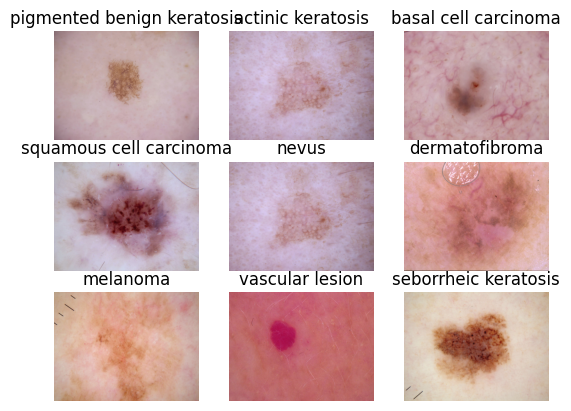

In [9]:
import matplotlib.pyplot as plt
num=0
for dirpath, dirnames, filenames in os.walk(str(trained_path)):
    for filename in [f for f in filenames if f.endswith(".jpg")][:1]:
        img = PIL.Image.open(str(dirpath)+"/"+str(filename))
        plt.subplot(3,3,num+1)
        plt.title(str(dirpath).split('/')[-1])
        plt.axis('off')
        plt.imshow(img)
        num=num+1

The `image_batch` is a tensor of the shape `(32, 180, 180, 3)`. This is a batch of 32 images of shape `180x180x3` (the last dimension refers to color channels RGB). The `label_batch` is a tensor of the shape `(32,)`, these are corresponding labels to the 32 images.

`Dataset.cache()` keeps the images in memory after they're loaded off disk during the first epoch.

`Dataset.prefetch()` overlaps data preprocessing and model execution while training.

In [10]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

<h2><a id="model_0">4. Model 0 (with BatchNormalization layers)</a></h2>

<h3><a id="creating_model_0">4.1 Creating the model</a></h3>

In [11]:
model=Sequential([
    tf.keras.layers.Rescaling(scale=1./255., offset=0.0,),

    Conv2D(32,(3,3),input_shape=(img_height,img_width,3),activation='relu',padding='same'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.1),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.1),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.25),
    Dense(9, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<h3><a id="compiling_model_0">4.2 Compiling the model</a></h3>

In [12]:
### Selecting an appropriate optimiser and loss function
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

<h3><a id="training_model_0">4.3 Training the model </a></h3>

In [13]:
epochs = 20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 126ms/step - accuracy: 0.1627 - loss: 4.5164 - val_accuracy: 0.2886 - val_loss: 1.9476
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.2709 - loss: 1.9460 - val_accuracy: 0.3915 - val_loss: 1.8581
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.3220 - loss: 1.8476 - val_accuracy: 0.3937 - val_loss: 1.8368
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.3916 - loss: 1.7459 - val_accuracy: 0.4362 - val_loss: 1.5838
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4079 - loss: 1.6120 - val_accuracy: 0.4497 - val_loss: 1.6173
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4765 - loss: 1.5098 - val_accuracy: 0.4586 - val_loss: 1.5935
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5325 - loss: 1.3947 - val_accuracy: 0.4877 - val_loss: 1.4909
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5483 - loss: 1.2809 - val_accuracy: 0.5034 -

In [14]:
# Viewing the summary of all layers
display(
    model.summary(),
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 129600)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    16,588,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,828,445 (190.08 MB)

 Trainable params: 16,609,481 (63.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 33,218,964 (126.72 MB)

None

<h3><a id="visualize_results_0">4.4 Visualizing training results </a></h3>

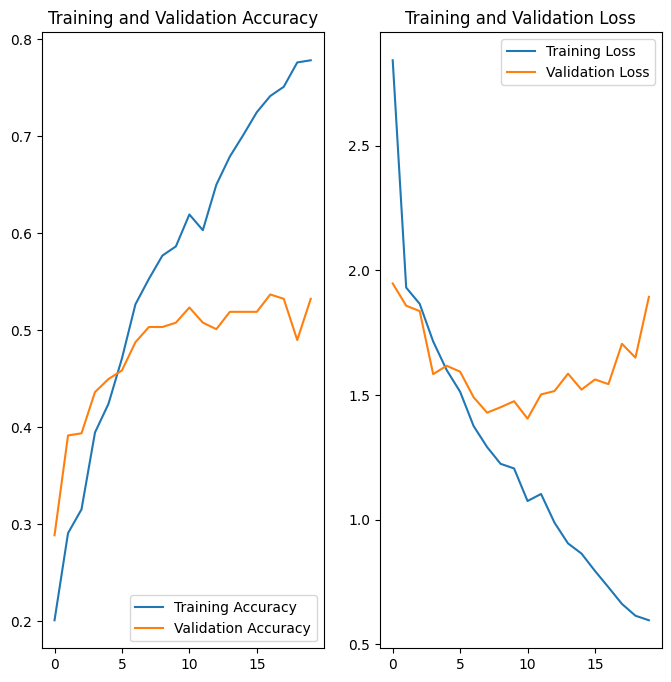

None

In [15]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
display(plt.show())

<h3><a id="observations_0">4.5 Observations </a></h3>

-  The accuracy of the model for the **Training data set** is at **78%**. But the **Validation accuracy** is not in par with the training accuracy.
-  It is only at **53%**. The validation loss as observed is very high.
-  This could also be indicative of some **Overfit** in the model.
-  We could add some `Dropout` layers and remove the `BatchNormalization` layers.
-  And by adding a few more layers, we could improve the accuracy by trying to extract more features.

<h2><a id="model_1">5. Model 1  </a></h2>

<h3><a id="creating_model_1">5.1 Creating the Model </a></h3>

In [16]:
model_update=Sequential([
    tf.keras.layers.Rescaling(scale=1./255., offset=0.0,),

    Conv2D(32,(3,3),input_shape=(img_height,img_width,3),activation='relu',padding='same'),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.7),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.7),

    Conv2D(128,(3,3),activation='relu',padding='same'),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.7),

    Flatten(),
    Dense(100, activation='relu'),
    Dropout(0.25),
    Dense(9, activation='softmax')
])

<h3><a id="compiling_model_1">5.2 Compiling the model  </a></h3>

In [17]:
model_update.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

<h3><a id="training_model_1">5.3 Training the model </a></h3>

In [18]:
epochs = 20
history = model_update.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 176ms/step - accuracy: 0.1980 - loss: 2.1743 - val_accuracy: 0.1924 - val_loss: 2.0539
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.1848 - loss: 2.0242 - val_accuracy: 0.1924 - val_loss: 2.0253
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.1721 - loss: 2.0538 - val_accuracy: 0.1924 - val_loss: 2.0273
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.2079 - loss: 2.0308 - val_accuracy: 0.2058 - val_loss: 2.0583
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.1816 - loss: 2.0436 - val_accuracy: 0.1924 - val_loss: 2.0252
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.1983 - loss: 2.0120 - val_accuracy: 0.2058 - val_loss: 2.0236
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.2001 - loss: 2.0422 - val_accuracy: 0.2058 - val_loss: 2.0284
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.1819 - loss: 2.0193 - val_accuracy: 0.2103 -

<h3><a id="visualize_results_1">5.4 Visualizing the results  </a></h3>

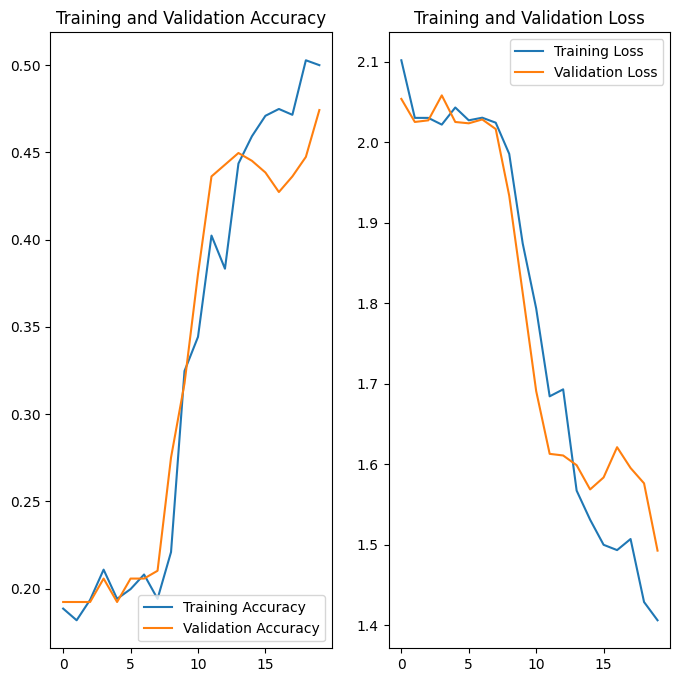

None

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
display(plt.show())

<h3><a id="observations_1">5.5 Observations </a></h3>

-  The model accuracy for **Train data set** has dropped to nearly **45%**.
-  The accuracy for the **Validation set** is at **40%**.
-  This is a much better model compared to the previous model as there seems to be **No Overfit** with the training accuracy **45%** and validation accuracy at **40%**.

<h2><a id="Data_Augmentation">6. Data Augmentation </a></h2>

<h3><a id="specifying_augmentation">6.1 Specifying the Augmentation</a></h3>

In [20]:
data_augmentation=tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2)
])

<h3><a id="visualizing_augmented_data">6.2 Visualizing the Augmented Data</a></h3>

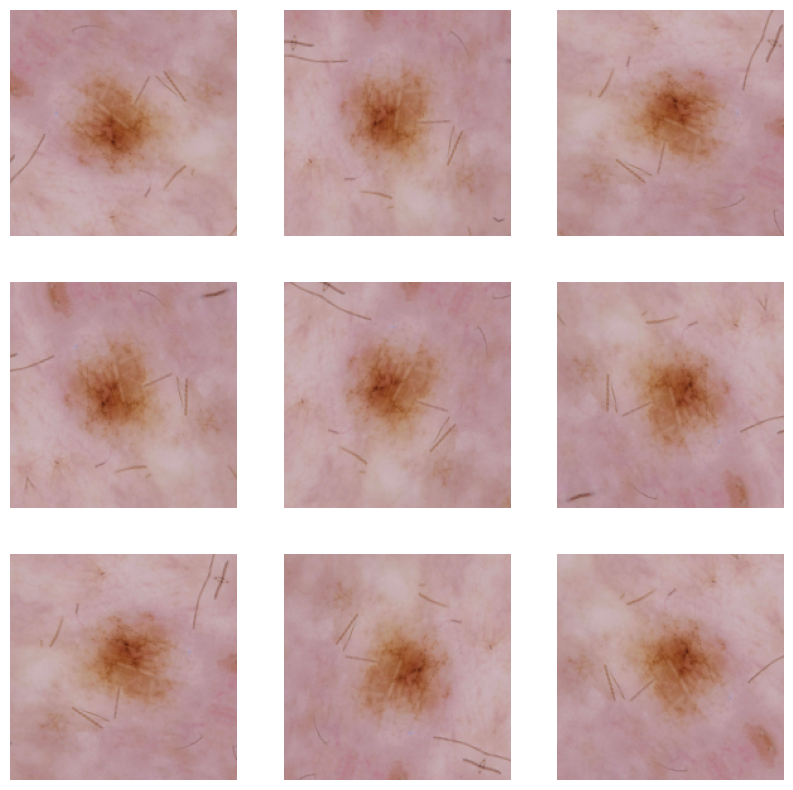

In [21]:
image, label = next(iter(train_ds))
image=np.array(image,np.int32)
plt.figure(figsize=(10, 10))
for i in range(9):
  augmented_image = data_augmentation(image)
  ax = plt.subplot(3, 3, i + 1)
  augmented_image1=np.array(augmented_image[0],np.int32)
  plt.imshow((augmented_image1))
  plt.axis("off")

<h2><a id="model_2">7. Model 2 (using Data Augmentation) </a></h2>

<h3><a id="creating_model_2">7.1 Creating the Model </a></h3>

In [22]:
model_augmented=Sequential([
    tf.keras.layers.Rescaling(scale=1./255., offset=0.0,),

    data_augmentation,

    Conv2D(32,(3,3),input_shape=(img_height,img_width,3),activation='relu',padding='same'),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.7),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.7),

    Conv2D(128,(3,3),activation='relu',padding='same'),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.7),

    Flatten(),
    Dense(100, activation='relu'),
    Dropout(0.25),
    Dense(9, activation='softmax')
])

<h3><a id="compiling_model_2">7.2 Compiling the model </a></h3>

In [23]:
model_augmented.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

<h3><a id="training_model_2">7.3 Training the model </a></h3>

In [24]:
epochs = 20
history = model_augmented.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 14s 136ms/step - accuracy: 0.1961 - loss: 2.4947 - val_accuracy: 0.2058 - val_loss: 2.0386
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.1807 - loss: 2.0449 - val_accuracy: 0.1499 - val_loss: 2.0292
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.2047 - loss: 2.0223 - val_accuracy: 0.1924 - val_loss: 2.0216
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - accuracy: 0.1763 - loss: 2.0289 - val_accuracy: 0.2640 - val_loss: 1.9520
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - accuracy: 0.2690 - loss: 1.9177 - val_accuracy: 0.2931 - val_loss: 1.8813
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.3147 - loss: 1.8564 - val_accuracy: 0.3199 - val_loss: 1.8222
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.3349 - loss: 1.7697 - val_accuracy: 0.2908 - val_loss: 1.8514
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.3757 - loss: 1.7154 - val_accuracy: 0

<h3><a id="visualize_results_2">7.4 Visualizing the results  </a></h3>

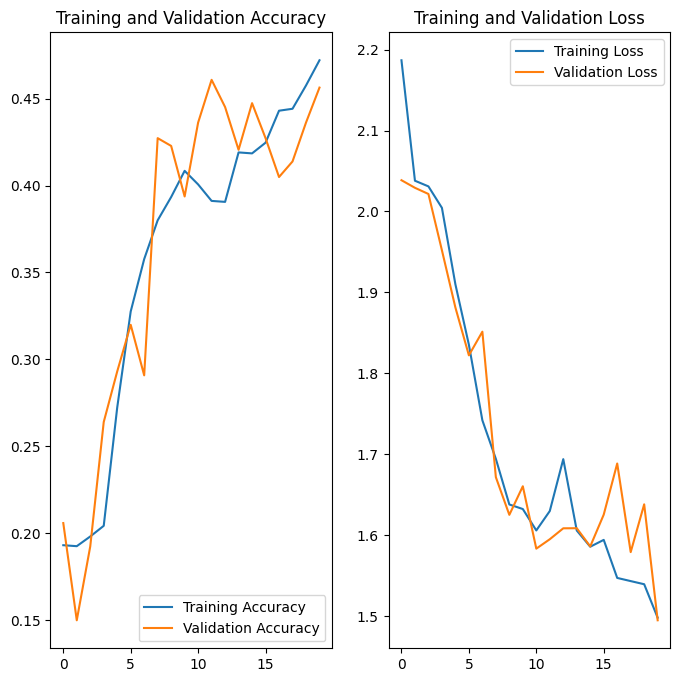

None

In [25]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
display(plt.show())

<h3><a id="observations_2">7.5  Observations </a></h3>

-  The model accuracy for **Train data set** has gone up to nearly **48%**.
-  The accuracy for the **Validation set** is also at **48%**.
-  This is a much better model compared to the previous two models as there seems to be **No Overfit** with the training accuracy **48%** and validation accuracy at **48%**.
-  `Data Augmentation` has improved the model performance.

<h2><a id="Checking_for_Class_Imbalance">8. Checking for Class Imbalance </a></h2>

In [26]:
for i in class_names:
    directory =trained_path+i+'/'
    class_directory = pathlib.Path(directory)
    length=len(list(class_directory.glob('*.jpg')))
    display(f'{i} has {length} samples.')

'actinic keratosis has 114 samples.'

'basal cell carcinoma has 376 samples.'

'dermatofibroma has 95 samples.'

'melanoma has 438 samples.'

'nevus has 357 samples.'

'pigmented benign keratosis has 462 samples.'

'seborrheic keratosis has 77 samples.'

'squamous cell carcinoma has 181 samples.'

'vascular lesion has 139 samples.'

-  The samples of various classes are not in equal proportion.
-  There is a significant **Class Imbalance** observed.
-  The class with the least number of samples is `Seborrheic Keratosis` with **77**.
-  The class that dominates the data in terms of proportionate number of samples is `Pigmented Benign Keratosis` with sample size of **462**.

<h2><a id="Using_Augmentor_for_Class_Imbalance_Treatment">9. Using Augmentor for Class Imbalance Treatment</a></h2>

<h3><a id="Installing_augmentor">9.1 Installing Augmentor</a></h3>

In [27]:
!pip install Augmentor

To use `Augmentor`, the following general procedure is followed:

1. Instantiate a `Pipeline` object pointing to a directory containing your initial image data set.<br>
2. Define a number of operations to perform on this data set using your `Pipeline` object.<br>
3. Execute these operations by calling the `Pipeline’s` `sample()` method.


<h3><a id="Using_augmentor">9.2 Using Augmentor </a></h3>

In [28]:
path_to_training_dataset=trained_path
import Augmentor
for i in class_names:
    p = Augmentor.Pipeline(path_to_training_dataset + i)
    p.rotate(probability=0.7, max_left_rotation=10, max_right_rotation=10)
    p.sample(500) ## We are adding 500 samples per class to make sure that none of the classes are sparse.

Initialised with 114 image(s) found.
Output directory set to /root/.cache/kagglehub/datasets/jaiahuja/skin-cancer-detection/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train/actinic keratosis/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7967F84BBBF0>: 100%|██████████| 500/500 [00:18<00:00, 27.47 Samples/s]


Initialised with 376 image(s) found.
Output directory set to /root/.cache/kagglehub/datasets/jaiahuja/skin-cancer-detection/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train/basal cell carcinoma/output.

Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450 at 0x79677901D340>: 100%|██████████| 500/500 [00:13<00:00, 37.37 Samples/s]


Initialised with 95 image(s) found.
Output directory set to /root/.cache/kagglehub/datasets/jaiahuja/skin-cancer-detection/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train/dermatofibroma/output.

...

Processing <PIL.Image.Image image mode=RGB size=1024x768 at 0x796754309070>: 100%|██████████| 500/500 [00:31<00:00, 15.85 Samples/s]


Initialised with 181 image(s) found.
Output directory set to /root/.cache/kagglehub/datasets/jaiahuja/skin-cancer-detection/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train/squamous cell carcinoma/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7967F84869C0>: 100%|██████████| 500/500 [00:13<00:00, 36.43 Samples/s]


Initialised with 139 image(s) found.
Output directory set to /root/.cache/kagglehub/datasets/jaiahuja/skin-cancer-detection/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train/vascular lesion/output.

Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450 at 0x796800291A60>: 100%|██████████| 500/500 [00:13<00:00, 37.99 Samples/s]


Augmentor has stored the augmented images in the output sub-directory of each of the sub-directories of skin cancer types.. Lets take a look at total count of augmented images.

In [29]:
image_count_train = len(list(data_directory_train.glob('*/output/*.jpg')))
display(image_count_train)

4500

In [30]:
path_list = [x for x in glob(os.path.join(data_directory_train, '*','output', '*.jpg'))]

In [31]:
lesion_list_new = [os.path.basename(os.path.dirname(os.path.dirname(y))) for y in glob(os.path.join(data_directory_train, '*','output', '*.jpg'))]

In [32]:
dataframe_dict_new = dict(zip(path_list, lesion_list_new))

In [33]:
for i in class_names:
    directory =trained_path+i+'/'
    directory_out =trained_path+i+'/output/'
    class_directory = pathlib.Path(directory)
    class_directory_out = pathlib.Path(directory_out)
    length=len(list(class_directory.glob('*.jpg')))
    length_out=len(list(class_directory_out.glob('*.jpg')))
    length_tot=length+length_out
    display(f'{i} has {length_tot} samples.')

'actinic keratosis has 614 samples.'

'basal cell carcinoma has 876 samples.'

'dermatofibroma has 595 samples.'

'melanoma has 938 samples.'

'nevus has 857 samples.'

'pigmented benign keratosis has 962 samples.'

'seborrheic keratosis has 577 samples.'

'squamous cell carcinoma has 681 samples.'

'vascular lesion has 639 samples.'

<h3><a id="observations">9.3 Observations </a></h3>

-  The Augmentor has **helped decrease the imbalance** in class images and that can be viewed from above.

So, now we have added 500 images to all the classes to maintain some class balance. We can add more images as we want to improve training process.

<h2><a id="modelling_data_using_augmentor">10. Modelling Augmented Data</a></h2>

In [34]:
batch_size = 32
img_height = 180
img_width = 180

<h3><a id="creating_train_data_1">10.1 Creating the Train Data Set</a></h3>

In [35]:
data_directory_train=trained_path
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_directory_train,
  seed=123, label_mode='categorical',
  validation_split = 0.2,
  subset = 'training',
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 6739 files belonging to 9 classes.
Using 5392 files for training.


<h3><a id="creating_validation_data_1">10.2 Creating the Validation Data Set</a></h3>

In [36]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_directory_train,
  seed=123, label_mode='categorical',
  validation_split = 0.2,
  subset = 'validation',
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 6739 files belonging to 9 classes.
Using 1347 files for validation.


<h2><a id="model_3">11. Model 3 (using class rebalance) </a></h2>

<h3><a id="creating_model_3">11.1 Creating the Model</a></h3>

In [37]:
model_final=Sequential([
    tf.keras.layers.Rescaling(scale=1./255., offset=0.0,),

    Conv2D(32,(3,3),input_shape=(img_height,img_width,3),activation='relu',padding='same'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.1),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.1),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.25),
    Dense(9, activation='softmax')
])

<h3><a id="compiling_model_3">11.2 Compiling the Model </a></h3>

In [38]:
model_final.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

<h3><a id="training_model_3">11.3 Training the Model </a></h3>

In [39]:
epochs = 30

history = model_final.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 37s 178ms/step - accuracy: 0.1934 - loss: 2.9963 - val_accuracy: 0.4128 - val_loss: 1.6183
Epoch 2/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 24s 140ms/step - accuracy: 0.4242 - loss: 1.5622 - val_accuracy: 0.4365 - val_loss: 1.4959
Epoch 3/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 40s 136ms/step - accuracy: 0.4683 - loss: 1.3783 - val_accuracy: 0.4625 - val_loss: 1.4573
Epoch 4/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 23s 135ms/step - accuracy: 0.5265 - loss: 1.2372 - val_accuracy: 0.5397 - val_loss: 1.2328
Epoch 5/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 23s 133ms/step - accuracy: 0.5848 - loss: 1.1145 - val_accuracy: 0.6073 - val_loss: 1.0606
Epoch 6/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 23s 134ms/step - accuracy: 0.6357 - loss: 1.0027 - val_accuracy: 0.6437 - val_loss: 0.9935
Epoch 7/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 23s 134ms/step - accuracy: 0.6811 - loss: 0.8695 - val_accuracy: 0.5976 - val_loss: 1.1579
Epoch 8/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 41s 134ms/step - accuracy: 0.6947 - loss: 0

<h3><a id="visualize_results_3">11.4 Visualizing the model results </a></h3>

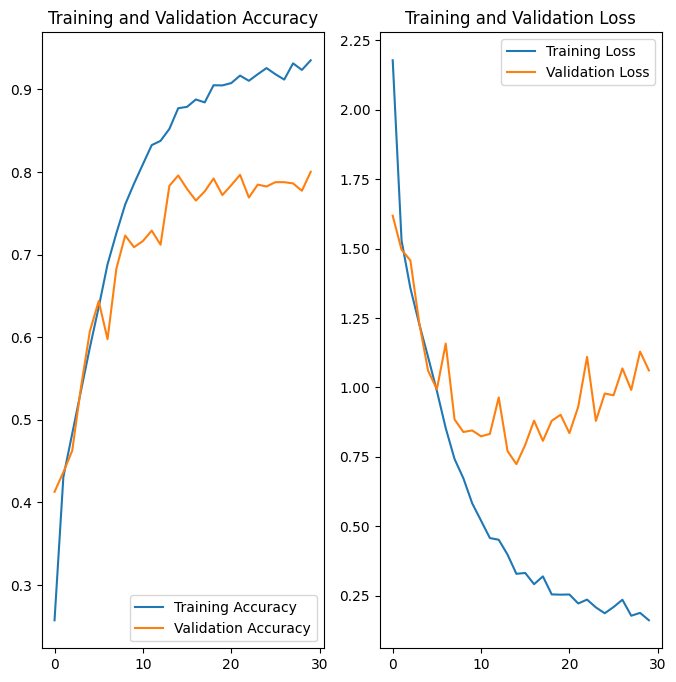

None

In [40]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
display(plt.show())

<h3><a id="observations_3">11.5 Observations</a></h3>

-  The training accuracy seems to be nearly **~90%**.
-  The validation accuracy is nearly **~80%**.
-  Though the model accuracy has improved, the **class rebalance** has helped **treat the overfitting to some extent**.
-  Much better models could be built or tried out using **more epochs and more layers**.

In [41]:
import datetime, pytz;
print("Current Time in IST:", datetime.datetime.now(pytz.utc).astimezone(pytz.timezone('Asia/Kolkata')).strftime('%Y-%m-%d %H:%M:%S'))

Current Time in IST: 2026-02-28 21:55:11


In [ ]:
# --- gcolab wrapper: list files in outputs/ ---
import os, datetime
_out_dir = 'outputs'
os.makedirs(_out_dir, exist_ok=True)
print(f"Files in {_out_dir}:")
_files = []
for _fn in os.listdir(_out_dir):
    _fp = os.path.join(_out_dir, _fn)
    if os.path.isfile(_fp):
        _st = os.stat(_fp)
        _files.append((datetime.datetime.fromtimestamp(_st.st_mtime).strftime('%Y-%m-%d %H:%M:%S'), _st.st_size, _fn))
_files.sort()
for _m, _s, _n in _files:
    if _s < 1024:
        _h = f"{_s} B"
    elif _s < 1024*1024:
        _h = f"{_s/1024:.2f} KB"
    else:
        _h = f"{_s/(1024*1024):.2f} MB"
    print(f"{_m}  {_h:>10}  {_n}")


In [ ]:
# --- gcolab wrapper: zip outputs/ -> outputs.zip ---
import os, shutil
os.makedirs('outputs', exist_ok=True)
shutil.make_archive('outputs', 'zip', 'outputs')
print('Created outputs.zip')
